# 🏥 MedAssist AI — Notebook 01: Data Exploration V6.0

## Version History
| Version | Changes |
|---------|--------|
| V6.0 | 7-feature ABCDE selection, ISIC 2019 integration, SCC/MEL/ACK/SEK rare-class augmentation |
| V5.0 | 7-feature ABCDE-aligned selection via Spearman correlation, removed itch/hurt/changed (ρ<0.05) |
| V4.2 | 11 clinical features |

## Purpose
- Exploratory Data Analysis of PAD-UFES-20
- Class distribution visualization
- Spearman correlation analysis for feature selection
- Validate 7-feature ABCDE selection (age, gender, grew, bleed, diameter_1, skin_cancer_history, elevation)

## CELL 1 — Imports & Setup

In [1]:
# ## CELL 1 — Imports & Setup
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/MedAssist_AI'
DATASET_PATH = os.path.join(BASE_PATH, 'dataset')
ISIC_PATH = os.path.join(BASE_PATH, 'dataset_isic2019')
MCR_PATH = os.path.join(BASE_PATH, 'dataset_mcr_sl')
RESULTS_PATH = os.path.join(BASE_PATH, 'results')
os.makedirs(RESULTS_PATH, exist_ok=True)

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

VERSION = 'V6.0'
CLASS_NAMES = ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']
NUM_CLASSES = 6

# ── Merge Configuration (matches 02_preprocessing exactly) ───
RARE_CLASSES = ['SCC', 'ACK', 'MEL', 'SEK']
ISIC_TARGET_PER_CLASS = {
    'SCC': 700,
    'ACK': 450,
    'MEL': 600,
    'SEK': 350,
}
MCR_CLASS_MAP = {
    'SCC': 'SCC',
    'AK': 'ACK',
    'MEL': 'MEL',
    'SK': 'SEK',
    'BCC': 'BCC',
    'NEV': 'NEV'
}
ISIC_CLASS_MAP = {
    'SCC': 'SCC',
    'AK': 'ACK',
    'MEL': 'MEL',
    'BKL': 'SEK'
}

SELECTED_FEATURES = ['age', 'gender', 'grew', 'bleed',
                     'diameter_1', 'skin_cancer_history', 'elevation']

print(f'✅ MedAssist AI {VERSION} — Unified Data Exploration')
print(f'📋 Datasets: PAD-UFES-20 + MCR-SL + ISIC 2019')


Mounted at /content/drive
✅ MedAssist AI V6.0 — Unified Data Exploration
📋 Datasets: PAD-UFES-20 + MCR-SL + ISIC 2019


## CELL 2 — Load Metadata

In [2]:
# ## CELL 2 — Load Metadata
# ── Load PAD-UFES-20 ─────────────────────────────────────────
metadata_path = None
# Check direct names first
for name in ['metadata.csv', 'metadata (1).csv', 'metadata_pad.csv']:
    test_path = os.path.join(DATASET_PATH, name)
    if os.path.exists(test_path):
        metadata_path = test_path
        break

# If not found directly, walk recursively to find metadata*.csv (excluding ISIC files)
if not metadata_path:
    for root, dirs, files in os.walk(DATASET_PATH):
        for f in files:
            if f.lower().startswith('metadata') and f.lower().endswith('.csv') and 'isic' not in f.lower():
                metadata_path = os.path.join(root, f)
                break
        if metadata_path:
            break

if not metadata_path:
    raise FileNotFoundError(f'❌ No valid PAD-UFES-20 metadata file found in {DATASET_PATH}')

print(f'✅ Found PAD-UFES-20 metadata at: {metadata_path}')

pad_df = pd.read_csv(metadata_path)
pad_df['source'] = 'PAD-UFES-20'
pad_df['clinical_complete'] = True

# Ensure img_id column exists
if 'img_id' not in pad_df.columns:
    for col in ['image_id', 'image', 'filename']:
        if col in pad_df.columns:
            pad_df['img_id'] = pad_df[col]
            break

# Build img_filename
if 'img_id' in pad_df.columns:
    pad_df['img_filename'] = pad_df['img_id'].apply(
        lambda x: str(x) if str(x).endswith('.png') else str(x) + '.png'
    )

# Encode clinical features for PAD
if 'gender' in pad_df.columns:
    gender_map = {'MALE': 1, 'FEMALE': 0, 'male': 1, 'female': 0, 'M': 1, 'F': 0}
    pad_df['gender'] = pad_df['gender'].map(gender_map)

bool_map = {'TRUE': 1.0, 'FALSE': 0.0, 'UNK': np.nan, True: 1.0, False: 0.0}
for feat in ['grew', 'bleed', 'elevation']:
    if feat in pad_df.columns:
        pad_df[feat] = pad_df[feat].map(bool_map)

if 'skin_cancer_history' in pad_df.columns:
    pad_df['skin_cancer_history'] = pad_df['skin_cancer_history'].map({True: 1.0, False: 0.0})

print(f'✅ PAD-UFES-20: {len(pad_df)} images')
print(f'📊 Classes: {pad_df["diagnostic"].value_counts().to_dict()}')

# ── Load MCR-SL ──────────────────────────────────────────────
mcr_unified = os.path.join(MCR_PATH, 'unified_diagnosis.xlsx')
mcr_lesion = os.path.join(MCR_PATH, 'lesion.xlsx')
mcr_subject = os.path.join(MCR_PATH, 'subject.xlsx')
mcr_image = os.path.join(MCR_PATH, 'image.xlsx')

mcr_df = None
if all(os.path.exists(p) for p in [mcr_unified, mcr_lesion, mcr_subject, mcr_image]):
    df_diag = pd.read_excel(mcr_unified)
    df_lesion = pd.read_excel(mcr_lesion)
    df_sub = pd.read_excel(mcr_subject)
    df_img = pd.read_excel(mcr_image)

    mcr_raw = df_diag.merge(df_lesion, on='lesion_id').merge(df_sub, on='subject_id').merge(df_img, on='lesion_id')
    mcr_raw = mcr_raw[mcr_raw['unified_diagnosis'].isin(MCR_CLASS_MAP.keys())].copy()
    mcr_raw['diagnostic'] = mcr_raw['unified_diagnosis'].map(MCR_CLASS_MAP)

    mcr_raw['age'] = mcr_raw['age']
    mcr_raw['gender'] = mcr_raw['sex'].map({'Male': 1, 'Female': 0})
    mcr_raw['diameter_1'] = mcr_raw['diameter']
    mcr_raw['skin_cancer_history'] = mcr_raw['h_skin_cancer'].map({'Yes': 1, 'No': 0})

    for feat in ['grew', 'bleed', 'elevation']:
        mcr_raw[feat] = np.nan

    mcr_df = mcr_raw[mcr_raw['diagnostic'].isin(RARE_CLASSES)].copy()
    mcr_df['source'] = 'MCR-SL'
    mcr_df['clinical_complete'] = True
    mcr_df['patient_id'] = 'MCR_' + mcr_df['subject_id'].astype(str)
    mcr_df['img_id'] = mcr_df['image_id'].astype(str)
    mcr_df['img_filename'] = mcr_df['image_id'].astype(str) + '.png'

    print(f'✅ MCR-SL: {len(mcr_df)} rare-class images loaded')
    print(f'📊 Classes: {mcr_df["diagnostic"].value_counts().to_dict()}')
else:
    print('⚠️ MCR-SL dataset not found, skipping')

# ── Load ISIC 2019 (Smart Selective) ─────────────────────────
isic_meta_path = os.path.join(ISIC_PATH, 'ISIC_2019_Training_Metadata.csv')
isic_gt_path = os.path.join(ISIC_PATH, 'ISIC_2019_Training_GroundTruth.csv')
isic_df = None

if os.path.exists(isic_meta_path) and os.path.exists(isic_gt_path):
    isic_meta = pd.read_csv(isic_meta_path)
    isic_ground = pd.read_csv(isic_gt_path)
    isic_raw = isic_meta.merge(isic_ground, on='image')

    # Map ISIC classes to our class names
    isic_raw['diagnostic'] = None
    for isic_class, target_class in ISIC_CLASS_MAP.items():
        isic_raw.loc[isic_raw[isic_class] == 1.0, 'diagnostic'] = target_class

    isic_raw = isic_raw[isic_raw['diagnostic'].notna()].copy()

    # Smart selective sampling: pick best images per class
    isic_sampled = []
    for diag, target_count in ISIC_TARGET_PER_CLASS.items():
        diag_df = isic_raw[isic_raw['diagnostic'] == diag].copy()
        if len(diag_df) == 0:
            continue

        # Clinical completeness score
        diag_df['clinical_score'] = (
            diag_df['age_approx'].notna().astype(int) +
            diag_df['sex'].notna().astype(int) +
            diag_df['anatom_site_general'].notna().astype(int)
        )

        diag_df = diag_df.sort_values('clinical_score', ascending=False)
        sampled = diag_df.head(target_count).copy()
        isic_sampled.append(sampled)
        print(f'   ISIC {diag}: took {len(sampled)}/{len(diag_df)} available')

    if isic_sampled:
        isic_df = pd.concat(isic_sampled, ignore_index=True)

        # Map clinical features
        isic_df['age'] = isic_df['age_approx']
        isic_df['gender'] = isic_df['sex'].map({'male': 1, 'female': 0})

        for feat in ['grew', 'bleed', 'diameter_1', 'skin_cancer_history', 'elevation']:
            isic_df[feat] = np.nan

        isic_df['source'] = 'ISIC-2019'
        isic_df['clinical_complete'] = False
        isic_df['img_id'] = isic_df['image'].astype(str)
        isic_df['img_filename'] = isic_df['image'].astype(str) + '.jpg'

        print(f'✅ ISIC 2019: {len(isic_df)} smart-selected images loaded')
        print(f'📊 Classes: {isic_df["diagnostic"].value_counts().to_dict()}')
else:
    print('⚠️ ISIC 2019 dataset not found, skipping')

# ── Unified Merge ────────────────────────────────────────────
df = pad_df.copy()

if mcr_df is not None:
    df = pd.concat([df, mcr_df], ignore_index=True)
if isic_df is not None:
    df = pd.concat([df, isic_df], ignore_index=True)

# Deduplicate by img_filename
df = df.drop_duplicates(subset=['img_filename'], keep='first').reset_index(drop=True)

print('=' * 60)
print(f'📊 UNIFIED DATASET SUMMARY')
print('=' * 60)
print(f'  Total images: {len(df):,}')
print(f'  Total classes: {df["diagnostic"].nunique()}')
print()

# Per-source breakdown
print('📦 By Source:')
for src in ['PAD-UFES-20', 'MCR-SL', 'ISIC-2019']:
    cnt = len(df[df['source'] == src])
    pct = cnt / len(df) * 100
    print(f'  {src:<12}: {cnt:5,} images ({pct:.1f}%)')

print()

# Per-class breakdown
print('📊 By Class (Unified):')
for cls in CLASS_NAMES:
    cnt = len(df[df['diagnostic'] == cls])
    pct = cnt / len(df) * 100
    bar = '█' * int(pct)
    print(f'  {cls}: {cnt:5,} ({pct:5.1f}%) {bar}')

# Clinical completeness
complete = df['clinical_complete'].sum()
print(f'\n🏥 Clinical completeness: {complete:,}/{len(df):,} ({100*complete/len(df):.1f}%)')


✅ Found PAD-UFES-20 metadata at: /content/drive/MyDrive/MedAssist_AI/dataset/metadata.csv
✅ PAD-UFES-20: 2298 images
📊 Classes: {'BCC': 845, 'ACK': 730, 'NEV': 244, 'SEK': 235, 'SCC': 192, 'MEL': 52}
✅ MCR-SL: 877 rare-class images loaded
📊 Classes: {'SEK': 671, 'ACK': 95, 'MEL': 68, 'SCC': 43}
   ISIC SCC: took 628/628 available
   ISIC ACK: took 450/867 available
   ISIC MEL: took 600/4522 available
   ISIC SEK: took 350/2624 available
✅ ISIC 2019: 2028 smart-selected images loaded
📊 Classes: {'SCC': 628, 'MEL': 600, 'ACK': 450, 'SEK': 350}
📊 UNIFIED DATASET SUMMARY
  Total images: 5,203
  Total classes: 6

📦 By Source:
  PAD-UFES-20 : 2,298 images (44.2%)
  MCR-SL      :   877 images (16.9%)
  ISIC-2019   : 2,028 images (39.0%)

📊 By Class (Unified):
  ACK: 1,275 ( 24.5%) ████████████████████████
  BCC:   845 ( 16.2%) ████████████████
  MEL:   720 ( 13.8%) █████████████
  NEV:   244 (  4.7%) ████
  SCC:   863 ( 16.6%) ████████████████
  SEK: 1,256 ( 24.1%) ████████████████████████



## CELL 3 — Class Distribution & Visualization

saved -> /content/drive/MyDrive/MedAssist_AI/results/class_distribution_unified_V6.0.png


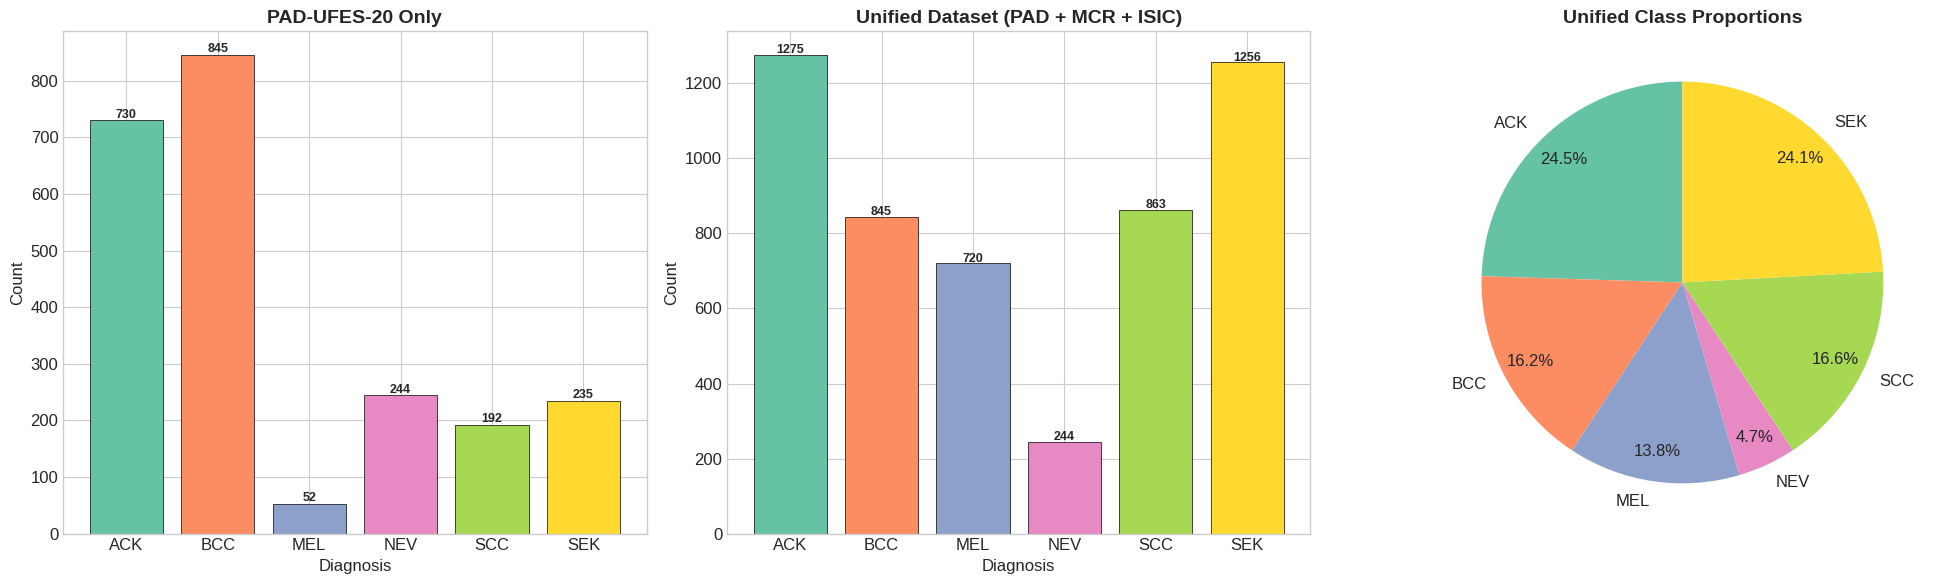

saved -> /content/drive/MyDrive/MedAssist_AI/results/source_distribution_V6.0.png


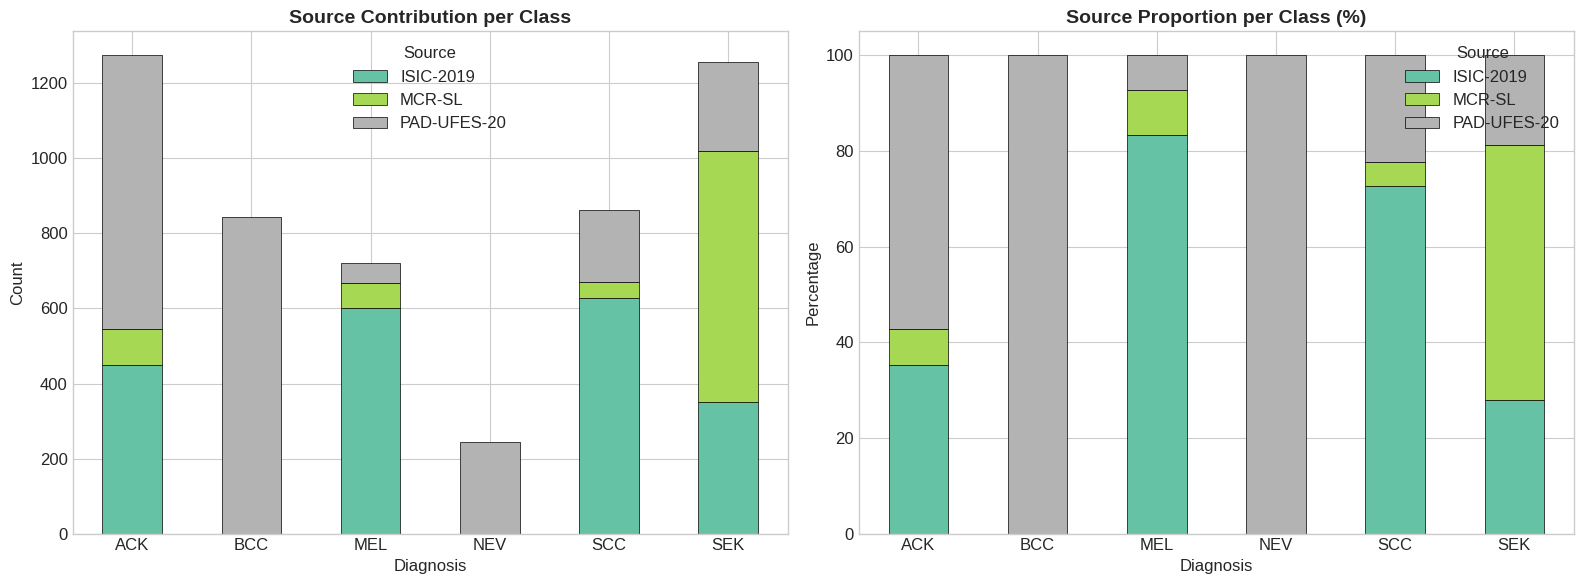


📊 Source × Class Table:
source      ISIC-2019  MCR-SL  PAD-UFES-20
diagnostic                                
ACK               450      95          730
BCC                 0       0          845
MEL               600      68           52
NEV                 0       0          244
SCC               628      43          192
SEK               350     671          235


In [3]:
# ## CELL 3 — Class Distribution & Visualization
# ── Class Distribution: Before vs After Merge ────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

colors = sns.color_palette('Set2', NUM_CLASSES)

# Plot 1: PAD-UFES-20 only
pad_counts = pad_df['diagnostic'].value_counts().reindex(CLASS_NAMES, fill_value=0)
bars = axes[0].bar(CLASS_NAMES, pad_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('PAD-UFES-20 Only', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Count')
for bar, cnt in zip(bars, pad_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(cnt),
                ha='center', fontweight='bold', fontsize=9)

# Plot 2: Unified merged dataset
unified_counts = df['diagnostic'].value_counts().reindex(CLASS_NAMES, fill_value=0)
bars = axes[1].bar(CLASS_NAMES, unified_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Unified Dataset (PAD + MCR + ISIC)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Diagnosis')
axes[1].set_ylabel('Count')
for bar, cnt in zip(bars, unified_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(cnt),
                ha='center', fontweight='bold', fontsize=9)

# Plot 3: Pie chart of unified
axes[2].pie(unified_counts.values, labels=CLASS_NAMES, autopct='%1.1f%%',
           colors=colors, startangle=90, pctdistance=0.85)
axes[2].set_title('Unified Class Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
save_path = os.path.join(RESULTS_PATH, 'class_distribution_unified_V6.0.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'saved -> {save_path}')
plt.show()

# ── Source Distribution per Class ─────────────────────────────
source_class = pd.crosstab(df['diagnostic'], df['source'])
source_class = source_class.reindex(CLASS_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar chart
source_class.plot(kind='bar', stacked=True, ax=axes[0],
                  colormap='Set2', edgecolor='black', linewidth=0.5)
axes[0].set_title('Source Contribution per Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Count')
axes[0].legend(title='Source')
axes[0].set_xticklabels(CLASS_NAMES, rotation=0)

# Show proportions
source_pct = source_class.div(source_class.sum(axis=1), axis=0) * 100
source_pct.plot(kind='bar', stacked=True, ax=axes[1],
                colormap='Set2', edgecolor='black', linewidth=0.5)
axes[1].set_title('Source Proportion per Class (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Diagnosis')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Source')
axes[1].set_xticklabels(CLASS_NAMES, rotation=0)

plt.tight_layout()
save_path = os.path.join(RESULTS_PATH, 'source_distribution_V6.0.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'saved -> {save_path}')
plt.show()

# Print table
print('\n📊 Source × Class Table:')
print(source_class.to_string())


## CELL 4 — Clinical Features Availability Check

In [4]:
# ## CELL 4 — Clinical Features Availability Check
# ── Clinical Features Availability ───────────────────────────
all_clinical_features = [
    'age', 'gender', 'grew', 'bleed', 'hurt', 'itch', 'changed',
    'diameter_1', 'diameter_2', 'skin_cancer_history', 'elevation',
    'region', 'smoke', 'drink', 'pesticide', 'background_father',
    'background_mother', 'has_piped_water', 'has_sewage_system',
    'fitspatrick'
]

available = [f for f in all_clinical_features if f in df.columns]
missing_feats = [f for f in all_clinical_features if f not in df.columns]

print(f'\n📋 Available clinical features: {len(available)}')
for f in available:
    null_pct = df[f].isnull().mean() * 100
    unique = df[f].nunique()
    print(f'  • {f:25s} — unique: {unique:3d}, nulls: {null_pct:.1f}%')

if missing_feats:
    print(f'\n⚠️ Missing features: {missing_feats}')

# Clinical completeness by source
print('\n🏥 Clinical Feature Availability by Source:')
for src in ['PAD-UFES-20', 'MCR-SL', 'ISIC-2019']:
    src_df = df[df['source'] == src]
    if len(src_df) == 0:
        continue
    print(f'\n  {src} ({len(src_df)} images):')
    for feat in SELECTED_FEATURES:
        if feat in src_df.columns:
            avail_pct = src_df[feat].notna().mean() * 100
            print(f'    {feat:25s}: {avail_pct:5.1f}% available')
        else:
            print(f'    {feat:25s}:   0.0% available')



📋 Available clinical features: 20
  • age                       — unique:  85, nulls: 0.0%
  • gender                    — unique:   2, nulls: 15.5%
  • grew                      — unique:   2, nulls: 63.6%
  • bleed                     — unique:   2, nulls: 55.9%
  • hurt                      — unique:   3, nulls: 55.8%
  • itch                      — unique:   3, nulls: 55.8%
  • changed                   — unique:   3, nulls: 55.8%
  • diameter_1                — unique: 117, nulls: 54.4%
  • diameter_2                — unique:  38, nulls: 71.3%
  • skin_cancer_history       — unique:   2, nulls: 55.3%
  • elevation                 — unique:   2, nulls: 55.9%
  • region                    — unique:  14, nulls: 55.8%
  • smoke                     — unique:   2, nulls: 71.3%
  • drink                     — unique:   2, nulls: 71.3%
  • pesticide                 — unique:   2, nulls: 71.3%
  • background_father         — unique:  13, nulls: 71.6%
  • background_mother         — unique

## CELL 5 — Spearman Correlation Analysis (Feature Selection)


📊 Spearman Correlation with Diagnosis (|ρ|):
  (Computed on clinically complete rows only)
  ✅ elevation                  ρ=0.3604  p=2.22e-71  ██████████████████
  ✅ grew                       ρ=0.3544  p=3.25e-57  █████████████████
  ✅ skin_cancer_history        ρ=0.2312  p=1.25e-29  ███████████
  ✅ age                        ρ=0.1933  p=4.23e-28  █████████
  ✅ diameter_1                 ρ=0.0860  p=2.73e-05  ████
  ❌ bleed                      ρ=0.0162  p=4.39e-01  
  ❌ gender                     ρ=0.0043  p=8.34e-01  

🎯 V6.0 Selected Features (ρ > 0.05 + clinical justification):
  ✅ Selected: ['age', 'gender', 'grew', 'bleed', 'diameter_1', 'skin_cancer_history', 'elevation']
  ❌ Removed:  ['itch', 'hurt', 'changed'] (ρ < 0.05, no clinical significance)
saved -> /content/drive/MyDrive/MedAssist_AI/results/feature_correlation_unified_V6.0.png


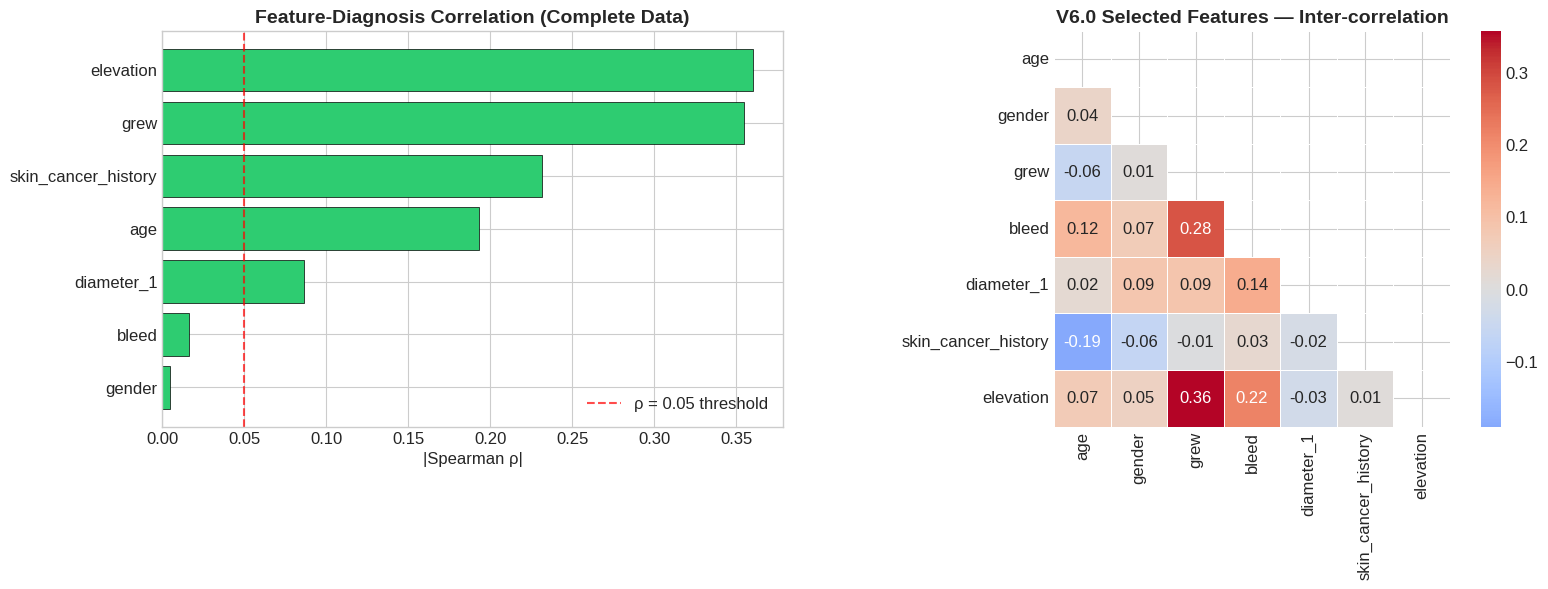

In [5]:
# ## CELL 5 — Spearman Correlation Analysis (Feature Selection)
# ── Spearman Correlation Analysis ────────────────────────────
from sklearn.preprocessing import LabelEncoder

# Use only rows with complete clinical data for correlation
df_complete = df[df['clinical_complete'] == True].copy()

le = LabelEncoder()
le.fit(CLASS_NAMES)
df_complete['diag_encoded'] = le.transform(df_complete['diagnostic'])

candidate_features = [
    'age', 'gender', 'grew', 'bleed', 'hurt', 'itch', 'changed',
    'diameter_1', 'skin_cancer_history', 'elevation'
]
candidate_features = [f for f in candidate_features if f in df_complete.columns]

results = []
for feat in candidate_features:
    col = pd.to_numeric(df_complete[feat], errors='coerce')
    valid_mask = col.notna()
    if valid_mask.sum() < 50:
        continue
    rho, pval = spearmanr(col[valid_mask], df_complete.loc[valid_mask, 'diag_encoded'])
    results.append({
        'Feature': feat,
        'Spearman_rho': abs(rho),
        'p_value': pval,
        'Significant': pval < 0.05,
        'abs_rho': abs(rho)
    })

corr_df = pd.DataFrame(results).sort_values('abs_rho', ascending=False)

print('\n📊 Spearman Correlation with Diagnosis (|ρ|):')
print('  (Computed on clinically complete rows only)')
print('=' * 60)
for _, row in corr_df.iterrows():
    sig = '✅' if row['Significant'] else '❌'
    bar = '█' * int(row['abs_rho'] * 50)
    print(f"  {sig} {row['Feature']:25s}  ρ={row['Spearman_rho']:.4f}  p={row['p_value']:.2e}  {bar}")

print('\n🎯 V6.0 Selected Features (ρ > 0.05 + clinical justification):')
selected_v6 = ['age', 'gender', 'grew', 'bleed', 'diameter_1', 'skin_cancer_history', 'elevation']
removed_v6 = ['itch', 'hurt', 'changed']
print(f'  ✅ Selected: {selected_v6}')
print(f'  ❌ Removed:  {removed_v6} (ρ < 0.05, no clinical significance)')

# Plot Spearman correlation bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_bar = ['#2ecc71' if f in selected_v6 else '#e74c3c' for f in corr_df['Feature']]
bars = axes[0].barh(corr_df['Feature'], corr_df['abs_rho'], color=colors_bar, edgecolor='black', linewidth=0.5)
axes[0].axvline(x=0.05, color='red', linestyle='--', alpha=0.7, label='ρ = 0.05 threshold')
axes[0].set_xlabel('|Spearman ρ|')
axes[0].set_title('Feature-Diagnosis Correlation (Complete Data)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].invert_yaxis()

# Correlation heatmap of selected features
selected_cols = [f for f in selected_v6 if f in df_complete.columns]
df_sel = df_complete[selected_cols].apply(pd.to_numeric, errors='coerce')
corr_matrix = df_sel.corr(method='spearman')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
           center=0, ax=axes[1], square=True, linewidths=0.5)
axes[1].set_title('V6.0 Selected Features — Inter-correlation', fontsize=14, fontweight='bold')

plt.tight_layout()
save_path = os.path.join(RESULTS_PATH, 'feature_correlation_unified_V6.0.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'saved -> {save_path}')
plt.show()


## CELL 6 — Age Distribution by Class

saved -> /content/drive/MyDrive/MedAssist_AI/results/age_distribution_unified_V6.0.png


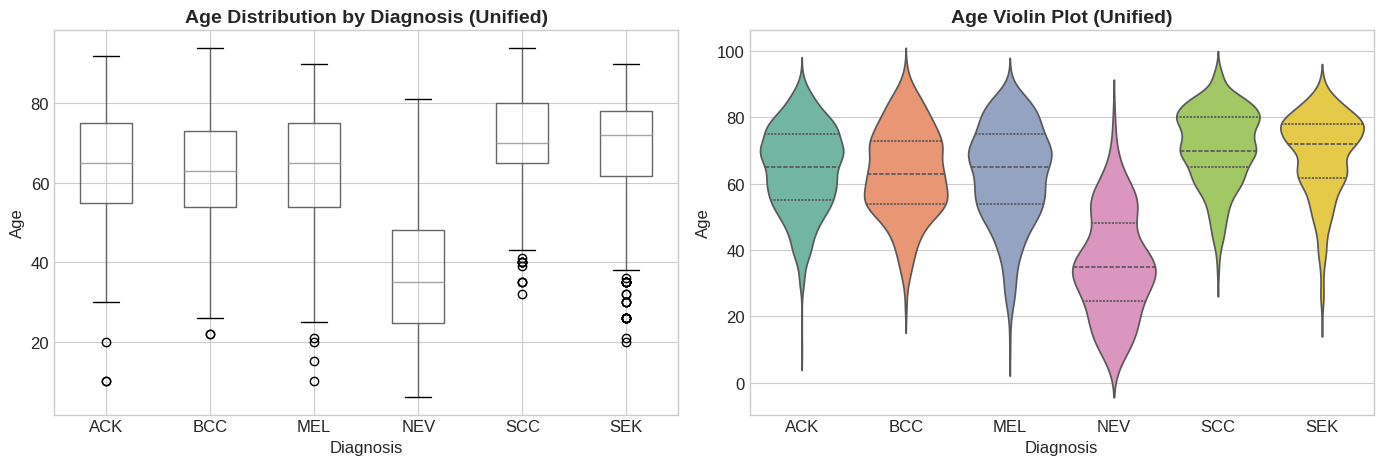


📊 Age statistics by class (unified):
            mean   std   min   max
diagnostic                        
ACK         64.4  12.9  10.0  92.0
BCC         63.1  13.5  22.0  94.0
MEL         62.4  14.8  10.0  90.0
NEV         35.6  15.6   6.0  81.0
SCC         70.8  11.6  32.0  94.0
SEK         68.5  12.7  20.0  90.0


In [6]:
# ## CELL 6 — Age Distribution by Class
# ── Age Distribution by Class ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='age', by='diagnostic', ax=axes[0])
axes[0].set_title('Age Distribution by Diagnosis (Unified)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Age')
plt.sca(axes[0])
plt.xticks(rotation=0)

sns.violinplot(data=df, x='diagnostic', y='age', ax=axes[1], palette='Set2',
              order=CLASS_NAMES, inner='quartile')
axes[1].set_title('Age Violin Plot (Unified)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Diagnosis')
axes[1].set_ylabel('Age')

plt.suptitle('')
plt.tight_layout()
save_path = os.path.join(RESULTS_PATH, 'age_distribution_unified_V6.0.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'saved -> {save_path}')
plt.show()

# Stats
print('\n📊 Age statistics by class (unified):')
print(df.groupby('diagnostic')['age'].describe()[['mean', 'std', 'min', 'max']].round(1))


## CELL 7 — Binary Features by Class

saved -> /content/drive/MyDrive/MedAssist_AI/results/binary_features_unified_V6.0.png


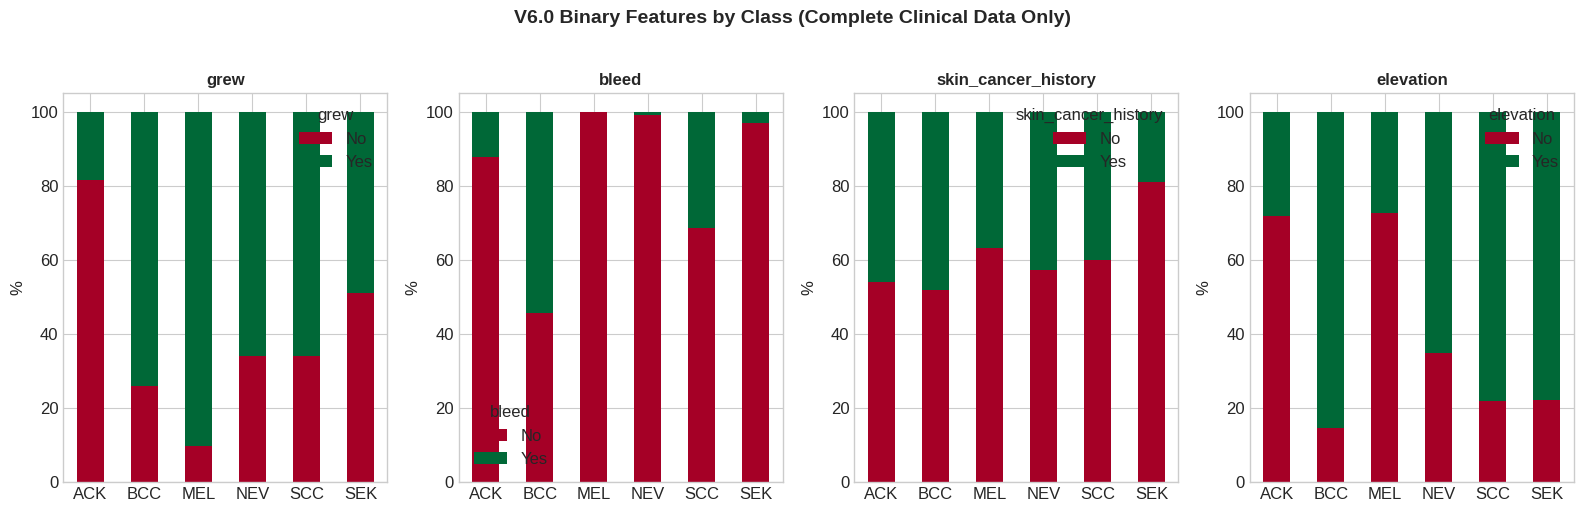

In [7]:
# ## CELL 7 — Binary Features by Class
# ── Binary Features by Class ─────────────────────────────────
# Only use rows with complete clinical data
df_bin = df[df['clinical_complete'] == True].copy()

binary_features = ['grew', 'bleed', 'skin_cancer_history', 'elevation']
binary_features = [f for f in binary_features if f in df_bin.columns]

fig, axes = plt.subplots(1, len(binary_features), figsize=(4*len(binary_features), 5))
if len(binary_features) == 1:
    axes = [axes]

for ax, feat in zip(axes, binary_features):
    ct = pd.crosstab(df_bin['diagnostic'], df_bin[feat], normalize='index') * 100
    ct.reindex(CLASS_NAMES).plot(kind='bar', stacked=True, ax=ax, colormap='RdYlGn')
    ax.set_title(f'{feat}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('%')
    ax.legend(title=feat, labels=['No', 'Yes'])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.suptitle('V6.0 Binary Features by Class (Complete Clinical Data Only)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_path = os.path.join(RESULTS_PATH, 'binary_features_unified_V6.0.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'saved -> {save_path}')
plt.show()


## CELL 8 — V6.0 Feature Selection Summary

In [8]:
# ## CELL 8 — V6.0 Feature Selection Summary
# ── V6.0 Final Summary ──────────────────────────────────────
print('=' * 70)
print('🎯 MedAssist AI V6.0 — Unified Dataset & Feature Selection Summary')
print('=' * 70)

# Dataset summary
print('\n📦 Dataset Composition:')
for src in ['PAD-UFES-20', 'MCR-SL', 'ISIC-2019']:
    cnt = len(df[df['source'] == src])
    pct = cnt / len(df) * 100
    print(f'  {src:<12}: {cnt:5,} images ({pct:.1f}%)')
print(f'  {"TOTAL":<12}: {len(df):5,} images')

# Expected val/test splits
print('\n📊 Expected Split Sizes (70/15/15):')
n_total = len(df)
for split_name, pct in [('Train', 0.70), ('Val', 0.15), ('Test', 0.15)]:
    n_split = int(n_total * pct)
    print(f'  {split_name:5s}: ~{n_split:,} images')
    for cls in CLASS_NAMES:
        cls_total = len(df[df['diagnostic'] == cls])
        cls_split = int(cls_total * pct)
        print(f'         {cls}: ~{cls_split}')

# Feature table
feature_table = [
    ('age',                  'Numeric',    'Incidence rises with age (ρ>0.15)'),
    ('gender',               'Binary M/F', 'Sex-based epidemiological differences'),
    ('grew',                 'Binary 1/0', 'ABCDE E — Evolution'),
    ('bleed',                'Binary 1/0', 'Ulceration / malignancy marker'),
    ('diameter_1',           'Numeric',    'ABCDE D — Diameter >6mm'),
    ('skin_cancer_history',  'Binary 1/0', 'Major personal risk factor'),
    ('elevation',            'Binary 1/0', 'Nodular lesion indicator'),
]

print(f'\n{"#":>3} {"Feature":25s} {"Type":12s} {"Clinical Justification"}')
print('-' * 70)
for i, (feat, ftype, reason) in enumerate(feature_table, 1):
    print(f'{i:3d} {feat:25s} {ftype:12s} {reason}')

print('\n❌ Removed vs V4.2: itch, hurt, changed (Spearman ρ<0.05)')
print(f'\n📊 Unified Dataset: {len(df):,} images, {NUM_CLASSES} classes, 3 sources')
complete = df['clinical_complete'].sum()
print(f'📊 Clinical completeness: {complete:,}/{len(df):,} ({100*complete/len(df):.1f}%)')
print('=' * 70)
print('✅ Ready for Notebook 02 (Unified Preprocessing)')

🎯 MedAssist AI V6.0 — Unified Dataset & Feature Selection Summary

📦 Dataset Composition:
  PAD-UFES-20 : 2,298 images (44.2%)
  MCR-SL      :   877 images (16.9%)
  ISIC-2019   : 2,028 images (39.0%)
  TOTAL       : 5,203 images

📊 Expected Split Sizes (70/15/15):
  Train: ~3,642 images
         ACK: ~892
         BCC: ~591
         MEL: ~503
         NEV: ~170
         SCC: ~604
         SEK: ~879
  Val  : ~780 images
         ACK: ~191
         BCC: ~126
         MEL: ~108
         NEV: ~36
         SCC: ~129
         SEK: ~188
  Test : ~780 images
         ACK: ~191
         BCC: ~126
         MEL: ~108
         NEV: ~36
         SCC: ~129
         SEK: ~188

  # Feature                   Type         Clinical Justification
----------------------------------------------------------------------
  1 age                       Numeric      Incidence rises with age (ρ>0.15)
  2 gender                    Binary M/F   Sex-based epidemiological differences
  3 grew                      Bin